In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 注释掉以下两行，禁用自定义字体设置
# plt.rcParams["font.sans-serif"] = ["SimHei"]
# plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 读取 Sephora 美妆商品数据
df = pd.read_csv("sephora_products.csv")

print("===== 数据概览 =====")
print(f"数据行数：{df.shape[0]} | 数据列数：{df.shape[1]}")
print("\n字段列表：")
print(list(df.columns))
print("\n前 3 行数据：")
df.head(3)

===== 数据概览 =====
数据行数：9168 | 数据列数：21

字段列表：
['id', 'brand', 'category', 'name', 'size', 'rating', 'number_of_reviews', 'love', 'price', 'value_price', 'URL', 'MarketingFlags', 'MarketingFlags_content', 'options', 'details', 'how_to_use', 'ingredients', 'online_only', 'exclusive', 'limited_edition', 'limited_time_offer']

前 3 行数据：


,id,brand,category,name,size,rating,number_of_reviews,love,price,value_price,...,MarketingFlags,MarketingFlags_content,options,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer
0,2218774,Acqua Di Parma,Fragrance,Blu Mediterraneo MINIATURE Set,5 x 0.16oz/5mL,4.0,4,3002,66.0,75.0,...,True,online only,no options,This enchanting set comes in a specially handc...,Suggested Usage:-Fragrance is intensified by t...,Arancia di Capri Eau de Toilette: Alcohol Dena...,1,0,0,0
1,2044816,Acqua Di Parma,Cologne,Colonia,0.7 oz/ 20 mL,4.5,76,2700,66.0,66.0,...,True,online only,- 0.7 oz/ 20 mL Spray - 1.7 oz/ 50 mL Eau d...,An elegant timeless scent filled with a fresh-...,no instructions,unknown,1,0,0,0
2,1417567,Acqua Di Parma,Perfume,Arancia di Capri,5 oz/ 148 mL,4.5,26,2600,180.0,180.0,...,True,online only,- 1oz/30mL Eau de Toilette - 2.5 oz/ 74 mL E...,Fragrance Family: Fresh Scent Type: Fresh Citr...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Li...,1,0,0,0


In [3]:
# ========== 数据清洗开始 ==========
print("===== 开始数据清洗 =====")

# 1. 删除完全空行
df = df.dropna(how="all")

# 2. 关键数值列类型转换
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")

# 3. 过滤无效价格
df = df[df["price"] > 0]

# 4. 品牌名称统一格式
df["brand"] = df["brand"].str.strip().str.upper()

# 5. 分类缺失值填充
df["category"] = df["category"].fillna("未知分类").str.strip()

print(f"\n清洗完成！剩余数据：{df.shape[0]} 行")
print("\n缺失值情况：")
print(df.isnull().sum()[df.isnull().sum() > 0])

===== 开始数据清洗 =====

清洗完成！剩余数据：9168 行

缺失值情况：
Series([], dtype: int64)


In [4]:
# ========== 核心数据分析 ==========
print("===== 开始数据分析 =====")

# 1. 商品数量 TOP10 品牌
brand_top10 = df["brand"].value_counts().head(10)
print("\n【1. 商品数量 TOP10 品牌】")
print(brand_top10)

# 2. 商品品类分布 TOP10
cate_top10 = df["category"].value_counts().head(10)
print("\n【2. 商品品类 TOP10】")
print(cate_top10)

# 3. 价格区间统计
df["price_range"] = pd.cut(
    df["price"],
    bins=[0, 30, 60, 100, 200, 500],
    labels=["0-30", "30-60", "60-100", "100-200", "200-500"]
)
price_dist = df["price_range"].value_counts().sort_index()
print("\n【3. 价格区间分布】")
print(price_dist)

# 4. 平均评分最高品牌（有效评论 ≥10）
brand_rating = df[df["number_of_reviews"] >= 10].groupby("brand")["rating"].agg(["mean", "count"]).round(2)
brand_rating_top10 = brand_rating.sort_values("mean", ascending=False).head(10)
print("\n【4. 评分 TOP10 品牌（评论≥10）】")
print(brand_rating_top10)

# 5. 最热门单品（评论数最多）
hot_items = df.sort_values("number_of_reviews", ascending=False)[
    ["brand", "name", "price", "rating", "number_of_reviews"]
].head(10)
print("\n【5. 热门单品 TOP10】")
print(hot_items)

===== 开始数据分析 =====

【1. 商品数量 TOP10 品牌】
brand
SEPHORA COLLECTION    496
CLINIQUE              234
TARTE                 170
TOM FORD              161
DIOR                  145
FRESH                 138
KIEHL'S SINCE 1851    126
LANCÔME               120
BUMBLE AND BUMBLE     104
MAKE UP FOR EVER       99
Name: count, dtype: int64

【2. 商品品类 TOP10】
category
Perfume                      665
Moisturizers                 451
Face Serums                  384
Value & Gift Sets            378
Face Wash & Cleansers        247
Face Masks                   230
Rollerballs & Travel Size    228
Hair Styling Products        224
Eye Palettes                 202
Lipstick                     191
Name: count, dtype: int64

【3. 价格区间分布】
price_range
0-30       3967
30-60      3084
60-100     1272
100-200     668
200-500     176
Name: count, dtype: int64

【4. 评分 TOP10 品牌（评论≥10）】
                    mean  count
brand                          
AETHER BEAUTY       5.00      6
YUNI                5.00      1
MON

/var/folders/d9/3cx3ty3j66167jkbshtx89z80000gn/T/ipykernel_5171/2622730018.py:24: UserWarning: Glyph 21830 (\N{CJK UNIFIED IDEOGRAPH-5546}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d9/3cx3ty3j66167jkbshtx89z80000gn/T/ipykernel_5171/2622730018.py:24: UserWarning: Glyph 21697 (\N{CJK UNIFIED IDEOGRAPH-54C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d9/3cx3ty3j66167jkbshtx89z80000gn/T/ipykernel_5171/2622730018.py:24: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d9/3cx3ty3j66167jkbshtx89z80000gn/T/ipykernel_5171/2622730018.py:24: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d9/3cx3ty3j66167jkbshtx89z80000gn/T/ipykernel_5171/2622730018.py:24: UserWarning: Glyph 29260 (\N{CJK UNIFIED IDEOGRAPH-724C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d9/3cx3ty3j6

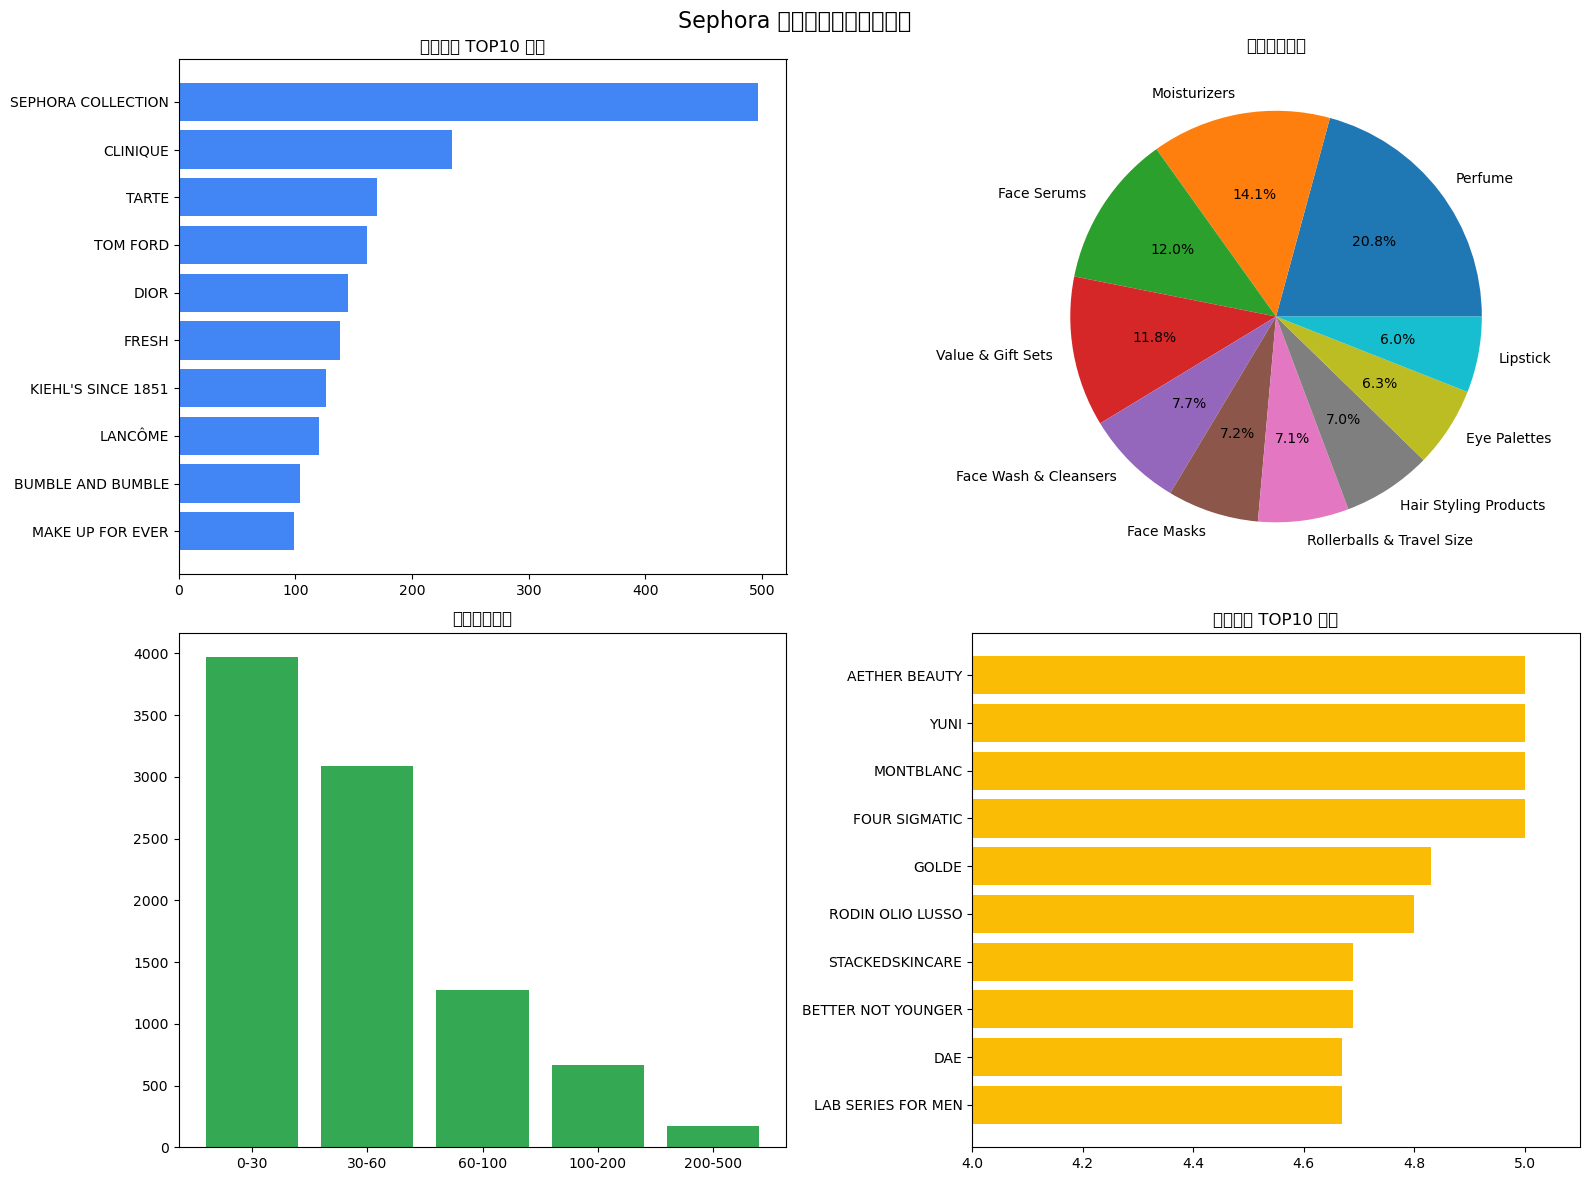


===== 开始输出文件 =====
✅ 全部完成！
📁 已生成：
  1. sephora_cleaned.csv（清洗后数据）
  2. sephora_analysis_report.txt（分析报告）


In [5]:
# ========== 可视化图表 ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Sephora 美妆商品数据分析报告", fontsize=16)

# 图1：品牌商品数
axes[0,0].barh(brand_top10.index, brand_top10.values, color="#4285F4")
axes[0,0].set_title("商品数量 TOP10 品牌")
axes[0,0].invert_yaxis()

# 图2：品类占比
axes[0,1].pie(cate_top10, labels=cate_top10.index, autopct="%1.1f%%")
axes[0,1].set_title("热门品类占比")

# 图3：价格分布
axes[1,0].bar(price_dist.index, price_dist.values, color="#34A853")
axes[1,0].set_title("价格区间分布")

# 图4：品牌评分
axes[1,1].barh(brand_rating_top10.index, brand_rating_top10["mean"], color="#FBBC05")
axes[1,1].set_title("平均评分 TOP10 品牌")
axes[1,1].invert_yaxis()
axes[1,1].set_xlim(4, 5.1)

plt.tight_layout()
plt.show()

# ========== 结果输出文件 ==========
print("\n===== 开始输出文件 =====")

# 输出清洗后数据
df.to_csv("sephora_cleaned.csv", index=False, encoding="utf-8-sig")

# 输出分析报告
with open("sephora_analysis_report.txt", "w", encoding="utf-8") as f:
    f.write("===== SEPHORA 美妆数据分析报告 =====\n")
    f.write(f"有效商品总数：{len(df)}\n\n")

    f.write("【TOP10 品牌】\n")
    f.write(brand_top10.to_string())

    f.write("\n\n【价格分布】\n")
    f.write(price_dist.to_string())

    f.write("\n\n【高分品牌】\n")
    f.write(brand_rating_top10.to_string())

    f.write("\n\n【热门单品】\n")
    f.write(hot_items.to_string(index=False))

print("✅ 全部完成！")
print("📁 已生成：")
print("  1. sephora_cleaned.csv（清洗后数据）")
print("  2. sephora_analysis_report.txt（分析报告）")